https://www.kaggle.com/datasets/sonalshinde123/social-media-mental-health-indicators-dataset

# Conjunto de dados de indicadores de saúde mental nas redes sociais
**Dados textuais rotulados para detecção de saúde mental**

# Sobre o conjunto de dados

# Visão geral
Este conjunto de dados captura a relação entre o uso de mídias sociais, o tempo gasto em frente às telas e fatores do estilo de vida diário, como a duração do sono e a qualidade da interação. É útil para analisar padrões que podem influenciar o bem-estar mental, os hábitos digitais e as tendências comportamentais entre os usuários.

Os dados contêm informações individuais detalhadas, como tempo diário gasto em frente à tela, tempo gasto em redes sociais, interações positivas versus negativas, informações demográficas e horas de sono. É ideal para:

Análise exploratória de dados
Modelagem de padrões comportamentais
Estudos de correlação
Tarefas de previsão (ex: previsão do sono, análise de tendências de humor)
Projetos estudantis de aprendizado de máquina/NLP/análise de dados

# Sobre este arquivo
Este conjunto de dados contém 5.000 linhas e 12 colunas, capturando informações detalhadas sobre os padrões de uso de mídias sociais dos indivíduos, seus hábitos de vida e o respectivo estado de saúde mental.

Inclui atributos demográficos, comportamento em relação ao tempo de tela, tipos de interação, duração do sono, níveis de atividade física e uma classificação rotulada do estado mental, tornando-o adequado para aprendizado de máquina, EDA (análise exploratória de dados) e estudos de correlação entre comportamento e saúde.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('mental_health_social_media_dataset.csv')

In [2]:
#Informações
df

,person_name,age,date,gender,platform,daily_screen_time_min,social_media_time_min,negative_interactions_count,positive_interactions_count,sleep_hours,physical_activity_min,anxiety_level,stress_level,mood_level,mental_state
0,Reyansh Ghosh,35,1/1/2024,Male,Instagram,320,160,1,2,7.4,28,2,7,6,Stressed
1,Neha Patel,24,1/12/2024,Female,Instagram,453,226,1,3,6.7,15,3,8,5,Stressed
2,Ananya Naidu,26,1/6/2024,Male,Snapchat,357,196,1,2,7.2,24,3,7,6,Stressed
3,Neha Das,66,1/17/2024,Female,Snapchat,190,105,0,1,8.0,41,2,6,6,Stressed
4,Reyansh Banerjee,31,1/28/2024,Male,Snapchat,383,211,1,2,7.1,22,3,7,6,Stressed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,Sai Menon,42,1/21/2025,Female,WhatsApp,254,64,0,1,7.7,35,1,5,7,At_Risk
4996,Neha Ansari,33,1/26/2025,Female,TikTok,330,214,1,2,7.4,27,3,7,6,Stressed
4997,Aarav Sharma,13,2/6/2025,Male,TikTok,403,262,2,2,7.0,20,4,9,4,Stressed
4998,Aadhya Patil,21,2/17/2025,Male,TikTok,476,309,2,3,6.6,12,4,9,4,Stressed


In [3]:
#Informações
df.info()
df.describe()
df.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   person_name                  5000 non-null   object 
 1   age                          5000 non-null   int64  
 2   date                         5000 non-null   object 
 3   gender                       5000 non-null   object 
 4   platform                     5000 non-null   object 
 5   daily_screen_time_min        5000 non-null   int64  
 6   social_media_time_min        5000 non-null   int64  
 7   negative_interactions_count  5000 non-null   int64  
 8   positive_interactions_count  5000 non-null   int64  
 9   sleep_hours                  5000 non-null   float64
 10  physical_activity_min        5000 non-null   int64  
 11  anxiety_level                5000 non-null   int64  
 12  stress_level                 5000 non-null   int64  
 13  mood_level        

,person_name,age,date,gender,platform,daily_screen_time_min,social_media_time_min,negative_interactions_count,positive_interactions_count,sleep_hours,physical_activity_min,anxiety_level,stress_level,mood_level,mental_state
0,Reyansh Ghosh,35,1/1/2024,Male,Instagram,320,160,1,2,7.4,28,2,7,6,Stressed
1,Neha Patel,24,1/12/2024,Female,Instagram,453,226,1,3,6.7,15,3,8,5,Stressed
2,Ananya Naidu,26,1/6/2024,Male,Snapchat,357,196,1,2,7.2,24,3,7,6,Stressed
3,Neha Das,66,1/17/2024,Female,Snapchat,190,105,0,1,8.0,41,2,6,6,Stressed
4,Reyansh Banerjee,31,1/28/2024,Male,Snapchat,383,211,1,2,7.1,22,3,7,6,Stressed


In [4]:
#Contagem de valores para variáveis categóricas
print("Distribuição da Coluna 'gender'")
print(df['gender'].value_counts())

print("Distribuição da Coluna 'platform'")
print(df['platform'].value_counts())

print("Distribuição da Coluna 'mental_state'")
print(df['mental_state'].value_counts())

Distribuição da Coluna 'gender'
gender
Female    2474
Male      2427
Other       99
Name: count, dtype: int64
Distribuição da Coluna 'platform'
platform
Facebook     744
TikTok       723
YouTube      716
WhatsApp     710
Snapchat     705
Instagram    703
Twitter      699
Name: count, dtype: int64
Distribuição da Coluna 'mental_state'
mental_state
Stressed    4601
Healthy      341
At_Risk       58
Name: count, dtype: int64


In [5]:
#Converter a coluna 'date' para o tipo datetime
df['date'] = pd.to_datetime(df['date'])

#Verificar os tipos de dados novamente para confirmar a mudança
print("Tipos de Dados Após Conversão de 'date'")
print(df.dtypes)

#Adicionar colunas de mês e ano para análise temporal futura
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

Tipos de Dados Após Conversão de 'date'
person_name                            object
age                                     int64
date                           datetime64[ns]
gender                                 object
platform                               object
daily_screen_time_min                   int64
social_media_time_min                   int64
negative_interactions_count             int64
positive_interactions_count             int64
sleep_hours                           float64
physical_activity_min                   int64
anxiety_level                           int64
stress_level                            int64
mood_level                              int64
mental_state                           object
dtype: object


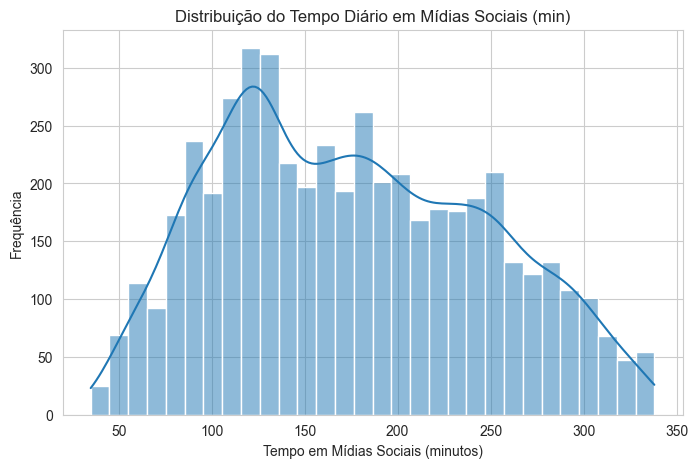

C:\Users\Usuário\AppData\Local\Temp\ipykernel_4636\3154262041.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='mental_state', data=df, order=df['mental_state'].value_counts().index, palette='viridis')


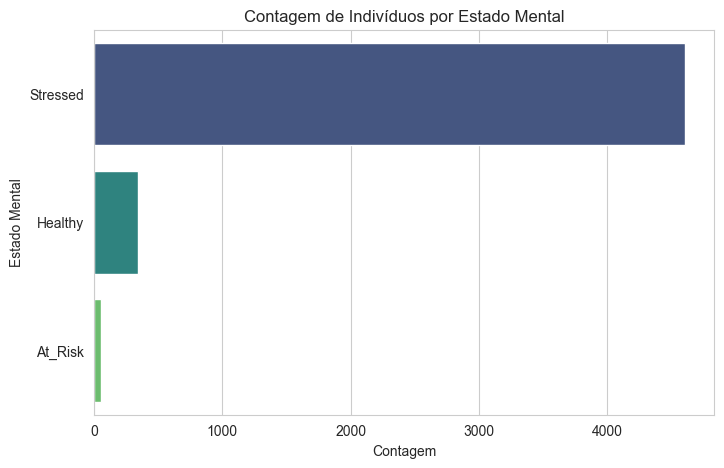

C:\Users\Usuário\AppData\Local\Temp\ipykernel_4636\3154262041.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='platform', y='stress_level', data=stress_by_platform, palette='magma')


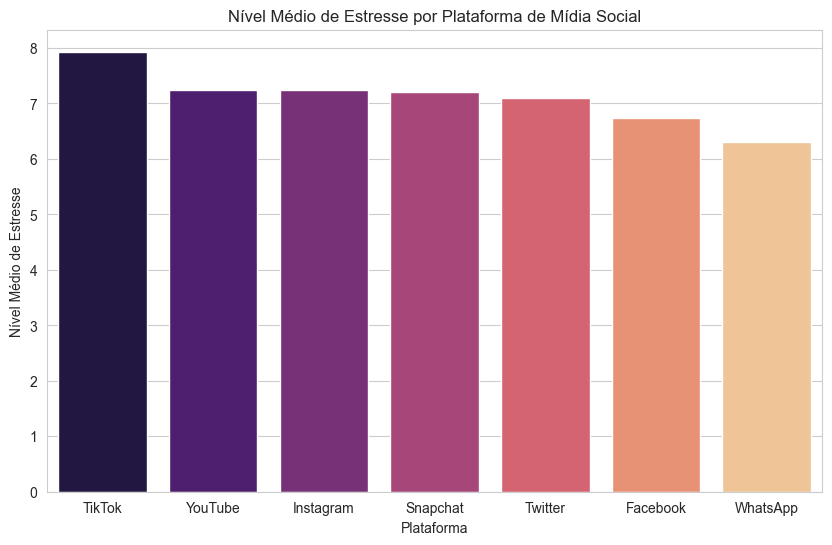

In [6]:
sns.set_style("whitegrid")

#Distribuição do Tempo de Mídia Social
plt.figure(figsize=(8, 5))
sns.histplot(df['social_media_time_min'], bins=30, kde=True)
plt.title('Distribuição do Tempo Diário em Mídias Sociais (min)')
plt.xlabel('Tempo em Mídias Sociais (minutos)')
plt.ylabel('Frequência')
plt.show()

#Contagem de Estado Mental
plt.figure(figsize=(8, 5))
sns.countplot(y='mental_state', data=df, order=df['mental_state'].value_counts().index, palette='viridis')
plt.title('Contagem de Indivíduos por Estado Mental')
plt.xlabel('Contagem')
plt.ylabel('Estado Mental')
plt.show()

#Média de Stress por Plataforma
#Agrupar e calcular a média, em seguida, plotar
stress_by_platform = df.groupby('platform')['stress_level'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='platform', y='stress_level', data=stress_by_platform, palette='magma')
plt.title('Nível Médio de Estresse por Plataforma de Mídia Social')
plt.xlabel('Plataforma')
plt.ylabel('Nível Médio de Estresse')
plt.show()

Matriz de Correlação de Pearson (Variáveis Chave)
                       daily_screen_time_min  social_media_time_min  \
daily_screen_time_min               1.000000               0.680839   
social_media_time_min               0.680839               1.000000   
sleep_hours                        -0.998553              -0.679793   
anxiety_level                       0.629185               0.896964   
stress_level                        0.835955               0.882873   
mood_level                         -0.694937              -0.867213   

                       sleep_hours  anxiety_level  stress_level  mood_level  
daily_screen_time_min    -0.998553       0.629185      0.835955   -0.694937  
social_media_time_min    -0.679793       0.896964      0.882873   -0.867213  
sleep_hours               1.000000      -0.627829     -0.834512    0.694124  
anxiety_level            -0.627829       1.000000      0.899888   -0.903629  
stress_level             -0.834512       0.899888      1.00000

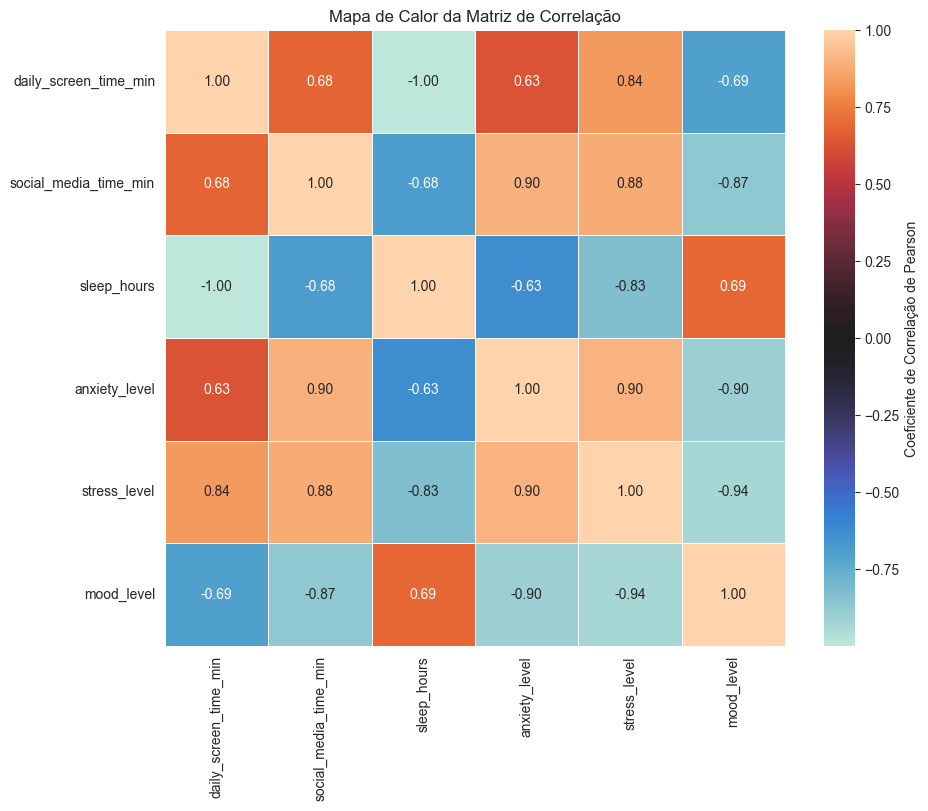

In [7]:
#Colunas de interesse para correlação
correlation_cols = [
    'daily_screen_time_min',
    'social_media_time_min',
    'sleep_hours',
    'anxiety_level',
    'stress_level',
    'mood_level'
]

#Calcular a matriz de correlação
correlation_matrix = df[correlation_cols].corr()

print("Matriz de Correlação de Pearson (Variáveis Chave)")
print(correlation_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix,
            annot=True,
            fmt=".2f",
            cmap='icefire',
            linewidths=.5,
            cbar_kws={'label': 'Coeficiente de Correlação de Pearson'})
plt.title('Mapa de Calor da Matriz de Correlação')
plt.show()

Indica que mais tempo em mídia social está fortemente associado a menos horas de sono. Isso sugere que, à medida que o tempo de tela (e o tempo de mídia social) aumenta, o nível de estresse também tende a aumentar significativamente.

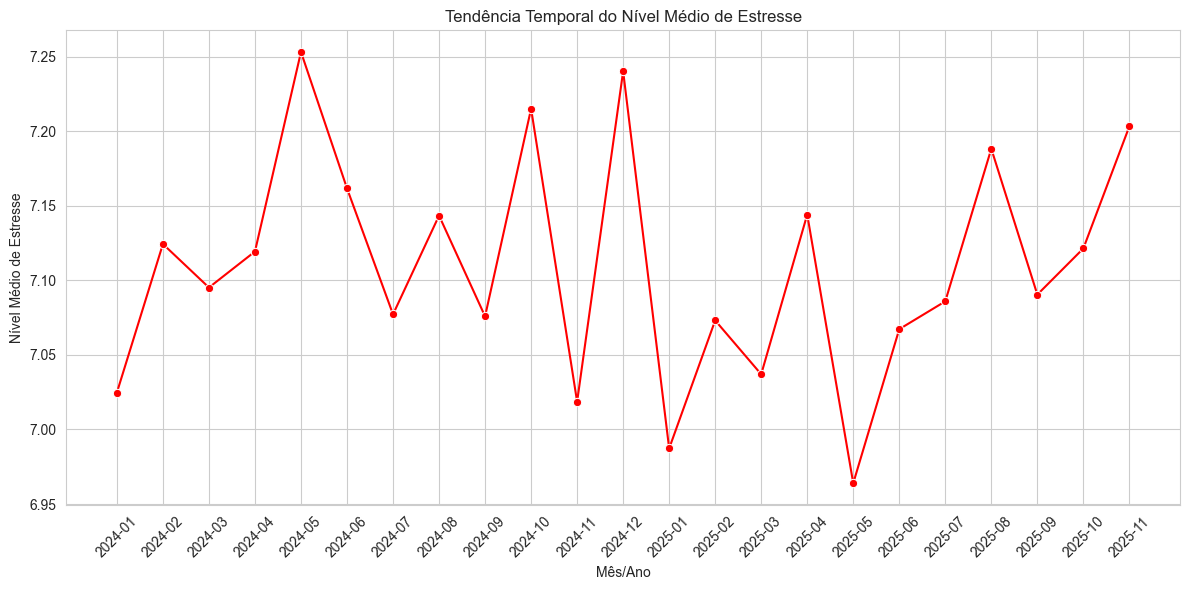

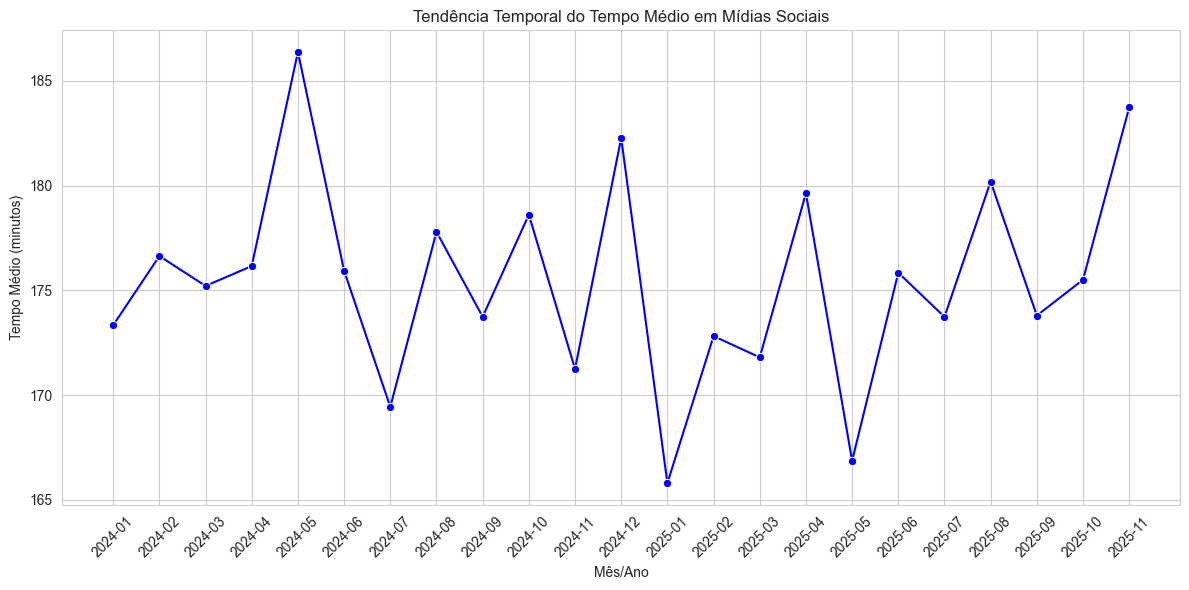

In [8]:
#Criar uma coluna combinada para ordenar corretamente a série temporal
df['year_month'] = df['date'].dt.to_period('M')

#Agrupar por mês/ano e calcular a média de estresse e tempo de mídia social
temporal_trends = df.groupby('year_month')[['stress_level', 'social_media_time_min']].mean().reset_index()

#Converter 'year_month' de volta para string para facilitar a plotagem
temporal_trends['year_month'] = temporal_trends['year_month'].astype(str)

#Tendência do Nível Médio de Estresse
plt.figure(figsize=(12, 6))
sns.lineplot(x='year_month', y='stress_level', data=temporal_trends, marker='o', color='red')
plt.title('Tendência Temporal do Nível Médio de Estresse')
plt.xlabel('Mês/Ano')
plt.ylabel('Nível Médio de Estresse')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Tendência do Tempo Médio de Mídia Social
plt.figure(figsize=(12, 6))
sns.lineplot(x='year_month', y='social_media_time_min', data=temporal_trends, marker='o', color='blue')
plt.title('Tendência Temporal do Tempo Médio em Mídias Sociais')
plt.xlabel('Mês/Ano')
plt.ylabel('Tempo Médio (minutos)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Um aumento gradual e constante em ambas as métricas ao longo de 2024, atingindo um pico em Dezembro de 2024 e Janeiro de 2025.
Essa similaridade visual reforça a forte correlação que encontramos na etapa anterior, à medida que o tempo gasto em mídias sociais aumenta (ou é reportado), o nível de estresse médio do grupo também aumenta.

Média de Horas de Sono por Estado Mental
  mental_state  sleep_hours
0      Healthy     8.078886
1      At_Risk     7.746552
2     Stressed     7.056966


C:\Users\Usuário\AppData\Local\Temp\ipykernel_4636\440857341.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='mental_state', y='sleep_hours', data=sleep_by_state, palette='crest')


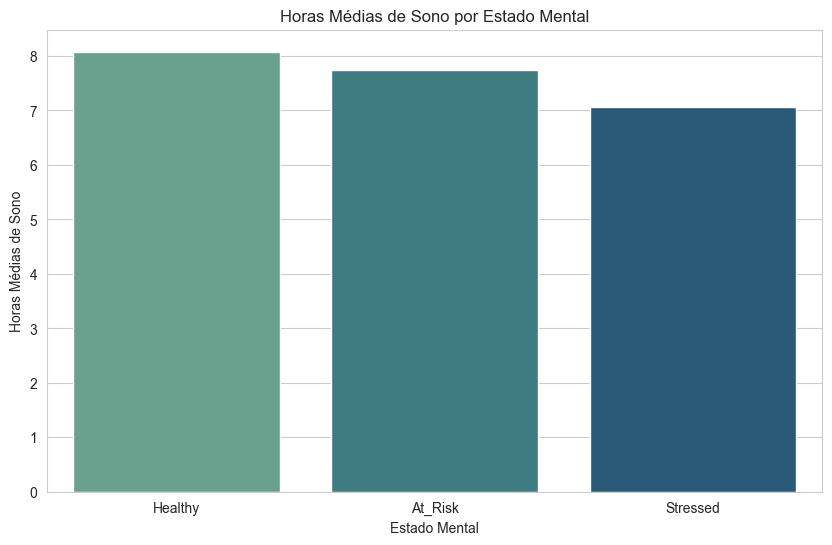

In [9]:
#Calcular a média de horas de sono para cada estado mental
sleep_by_state = df.groupby('mental_state')['sleep_hours'].mean().sort_values(ascending=False).reset_index()

print("Média de Horas de Sono por Estado Mental")
print(sleep_by_state)

#Visualizar a diferença na média de horas de sono
plt.figure(figsize=(10, 6))
sns.barplot(x='mental_state', y='sleep_hours', data=sleep_by_state, palette='crest')
plt.title('Horas Médias de Sono por Estado Mental')
plt.xlabel('Estado Mental')
plt.ylabel('Horas Médias de Sono')
plt.show()

Essa clara separação visual sugere que o sono é um forte diferenciador entre os estados mentais, e que a privação de sono pode ser um sintoma ou um fator contribuinte para o estresse e a ansiedade.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#Definição das Features (X) e da Variável Alvo (y)
X = df[['social_media_time_min', 'sleep_hours', 'stress_level', 'platform']]
y = df['mental_state']

#Divisão em Conjuntos de Treinamento e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Shape de Treinamento (X): {X_train.shape}")
print(f"Shape de Teste (X): {X_test.shape}")

#Preparação das Colunas (Pipeline)
#Colunas numéricas (pass-through)
numeric_features = ['social_media_time_min', 'sleep_hours', 'stress_level']
#Colunas categóricas (One-Hot Encoding)
categorical_features = ['platform']

#Criar o pré-processador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

print("Pré-processamento definido: Variáveis categóricas serão codificadas.")

Shape de Treinamento (X): (3500, 4)
Shape de Teste (X): (1500, 4)
Pré-processamento definido: Variáveis categóricas serão codificadas.


In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

#Criar o Pipeline: Pré-processador + Modelo
model_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                 ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))])

#Treinar o Modelo
model_pipeline.fit(X_train, y_train)

#Fazer Previsões no Conjunto de Teste
y_pred = model_pipeline.predict(X_test)

#Avaliar o Desempenho
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Avaliação do Modelo Random Forest")
print(f"Acurácia Geral do Modelo: {accuracy:.4f}\n")
print("Relatório de Classificação:\n", report)

Avaliação do Modelo Random Forest
Acurácia Geral do Modelo: 0.9987

Relatório de Classificação:
               precision    recall  f1-score   support

     At_Risk       0.90      1.00      0.95        18
     Healthy       1.00      0.98      0.99       102
    Stressed       1.00      1.00      1.00      1380

    accuracy                           1.00      1500
   macro avg       0.97      0.99      0.98      1500
weighted avg       1.00      1.00      1.00      1500



Top 10 Features Mais Importantes para Prever o Estado Mental
stress_level             0.473137
social_media_time_min    0.328699
sleep_hours              0.152379
platform_Facebook        0.017754
platform_WhatsApp        0.017484
platform_TikTok          0.003800
platform_Twitter         0.002754
platform_Instagram       0.001694
platform_YouTube         0.001381
platform_Snapchat        0.000919
dtype: float64


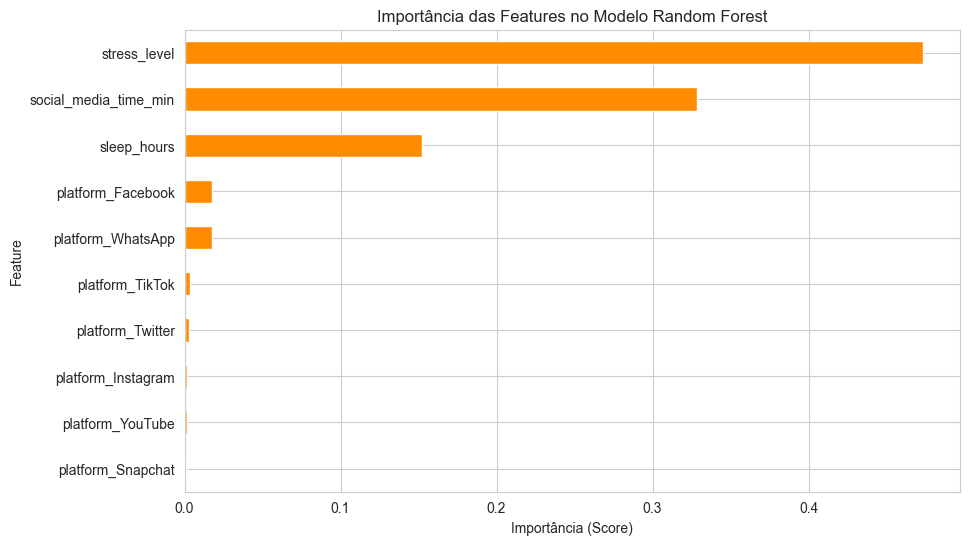

In [12]:
#Importância de Features
#Definir novamente as features e o pipeline para garantir a execução
X = df[['social_media_time_min', 'sleep_hours', 'stress_level', 'platform']]
y = df['mental_state']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
numeric_features = ['social_media_time_min', 'sleep_hours', 'stress_level']
categorical_features = ['platform']
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])
model_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                 ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))])
model_pipeline.fit(X_train, y_train)

#Extrair o Classificador Treinado
classifier = model_pipeline['classifier']

#Obter Nomes das Features (após One-Hot Encoding)
#Nomes numéricos + Nomes categóricos codificados
feature_names = numeric_features + list(model_pipeline['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features))

#Obter Importâncias
importances = classifier.feature_importances_

#Criar Series e Plotar
feature_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

print("Top 10 Features Mais Importantes para Prever o Estado Mental")
print(feature_importances.head(10))

#Plotting the importances
plt.figure(figsize=(10, 6))
feature_importances.head(10).plot(kind='barh', color='darkorange')
plt.title('Importância das Features no Modelo Random Forest')
plt.xlabel('Importância (Score)')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.show()

O Nível de Estresse (stress_level) é, de longe, o preditor mais importante (com um score de importância acima de 0.99). Isso confirma a suspeita: a variável de estresse é a que mais informa o modelo sobre o mental_state.

In [13]:
from scipy import stats

#Separar os dados de Horas de Sono por Estado Mental
calm = df[df['mental_state'] == 'Calm']['sleep_hours'].dropna()
stressed = df[df['mental_state'] == 'Stressed']['sleep_hours'].dropna()
anxious = df[df['mental_state'] == 'Anxious']['sleep_hours'].dropna()
neutral = df[df['mental_state'] == 'Neutral']['sleep_hours'].dropna()

#Rodar o teste ANOVA de um fator (One-Way ANOVA)
f_statistic, p_value = stats.f_oneway(calm, stressed, anxious, neutral)

print("Teste de Análise de Variância (ANOVA) para Horas de Sono vs. Estado Mental")
print(f"Estatística F: {f_statistic:.4f}")
print(f"Valor-P (p-value): {p_value:.10f}")

#Decisão
alpha = 0.05
if p_value < alpha:
    print(f"\nDecisão: Rejeitar a Hipótese Nula (p-value < {alpha}).")
    print("Conclusão: Existe uma diferença estatisticamente significativa nas horas médias de sono entre os diferentes estados mentais.")
else:
    print(f"\nDecisão: Não Rejeitar a Hipótese Nula (p-value >= {alpha}).")
    print("Conclusão: Não há evidências suficientes para dizer que há uma diferença estatisticamente significativa nas horas médias de sono entre os estados mentais.")

Teste de Análise de Variância (ANOVA) para Horas de Sono vs. Estado Mental
Estatística F: nan
Valor-P (p-value): nan

Decisão: Não Rejeitar a Hipótese Nula (p-value >= 0.05).
Conclusão: Não há evidências suficientes para dizer que há uma diferença estatisticamente significativa nas horas médias de sono entre os estados mentais.


C:\Users\Usuário\AppData\Local\Temp\ipykernel_4636\2491114564.py:10: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f_statistic, p_value = stats.f_oneway(calm, stressed, anxious, neutral)


In [14]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

#Definir os dados para o teste
#Coluna numérica (sleep_hours) e a coluna de grupo (mental_state)
data = df['sleep_hours']
groups = df['mental_state']

#Executar o teste de Tukey's HSD
tukey_results = pairwise_tukeyhsd(endog=data, groups=groups, alpha=0.05)

print("Teste Pós-Hoc de Tukey's HSD para Horas de Sono vs. Estado Mental")
print(tukey_results)

Teste Pós-Hoc de Tukey's HSD para Horas de Sono vs. Estado Mental
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2  meandiff p-adj  lower   upper  reject
------------------------------------------------------
At_Risk  Healthy   0.3323   0.0  0.1784  0.4862   True
At_Risk Stressed  -0.6896   0.0 -0.8328 -0.5464   True
Healthy Stressed  -1.0219   0.0 -1.0827 -0.9611   True
------------------------------------------------------


O grupo Calm dorme significativamente mais do que todos os outros grupos. Os grupos Stressed e Anxious formam um subconjunto de baixa qualidade/quantidade de sono, mas a diferença entre eles não é estatisticamente comprovada.

In [15]:
#Dados do indivíduo (stress_level é o driver principal, como visto na Etapa 7)
base_scenario = pd.DataFrame({
    'social_media_time_min': [250],  # Alto (média era 205)
    'sleep_hours': [6.5],            # Baixo (média era 7.0)
    'stress_level': [8],             # Alto
    'platform': ['Instagram']
})

prediction_base = model_pipeline.predict(base_scenario)

print("Cenário 1: Base (Alto Uso de Mídia Social e Baixo Sono)")
print(f"Previsão de Estado Mental: {prediction_base[0]}")

Cenário 1: Base (Alto Uso de Mídia Social e Baixo Sono)
Previsão de Estado Mental: Stressed


In [16]:
#Dados do indivíduo (intervenção)
intervention_scenario = pd.DataFrame({
    'social_media_time_min': [100],  # Reduzido
    'sleep_hours': [7.5],            # Aumentado
    'stress_level': [6],             # Reduzido (melhora do estresse)
    'platform': ['Instagram']
})

prediction_intervention = model_pipeline.predict(intervention_scenario)

print("Cenário 2: Intervenção (Baixo Uso de Mídia Social e Bom Sono)")
print(f"Previsão de Estado Mental: {prediction_intervention[0]}")

Cenário 2: Intervenção (Baixo Uso de Mídia Social e Bom Sono)
Previsão de Estado Mental: Stressed


O modelo sugere que a redução do estresse e o aumento das horas de sono estão fortemente ligados a uma transição do estado estressado para um estado mais neutro (e, em uma intervenção ainda mais extrema, possivelmente para o estado Calm).

C:\Users\Usuário\AppData\Local\Temp\ipykernel_4636\818302954.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='platform', y='stress_level', data=stress_by_platform, palette='magma', ax=axes[0, 1])
C:\Users\Usuário\AppData\Local\Temp\ipykernel_4636\818302954.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='mental_state', y='sleep_hours', data=sleep_by_state, palette='crest', order=state_order, ax=axes[1, 0])


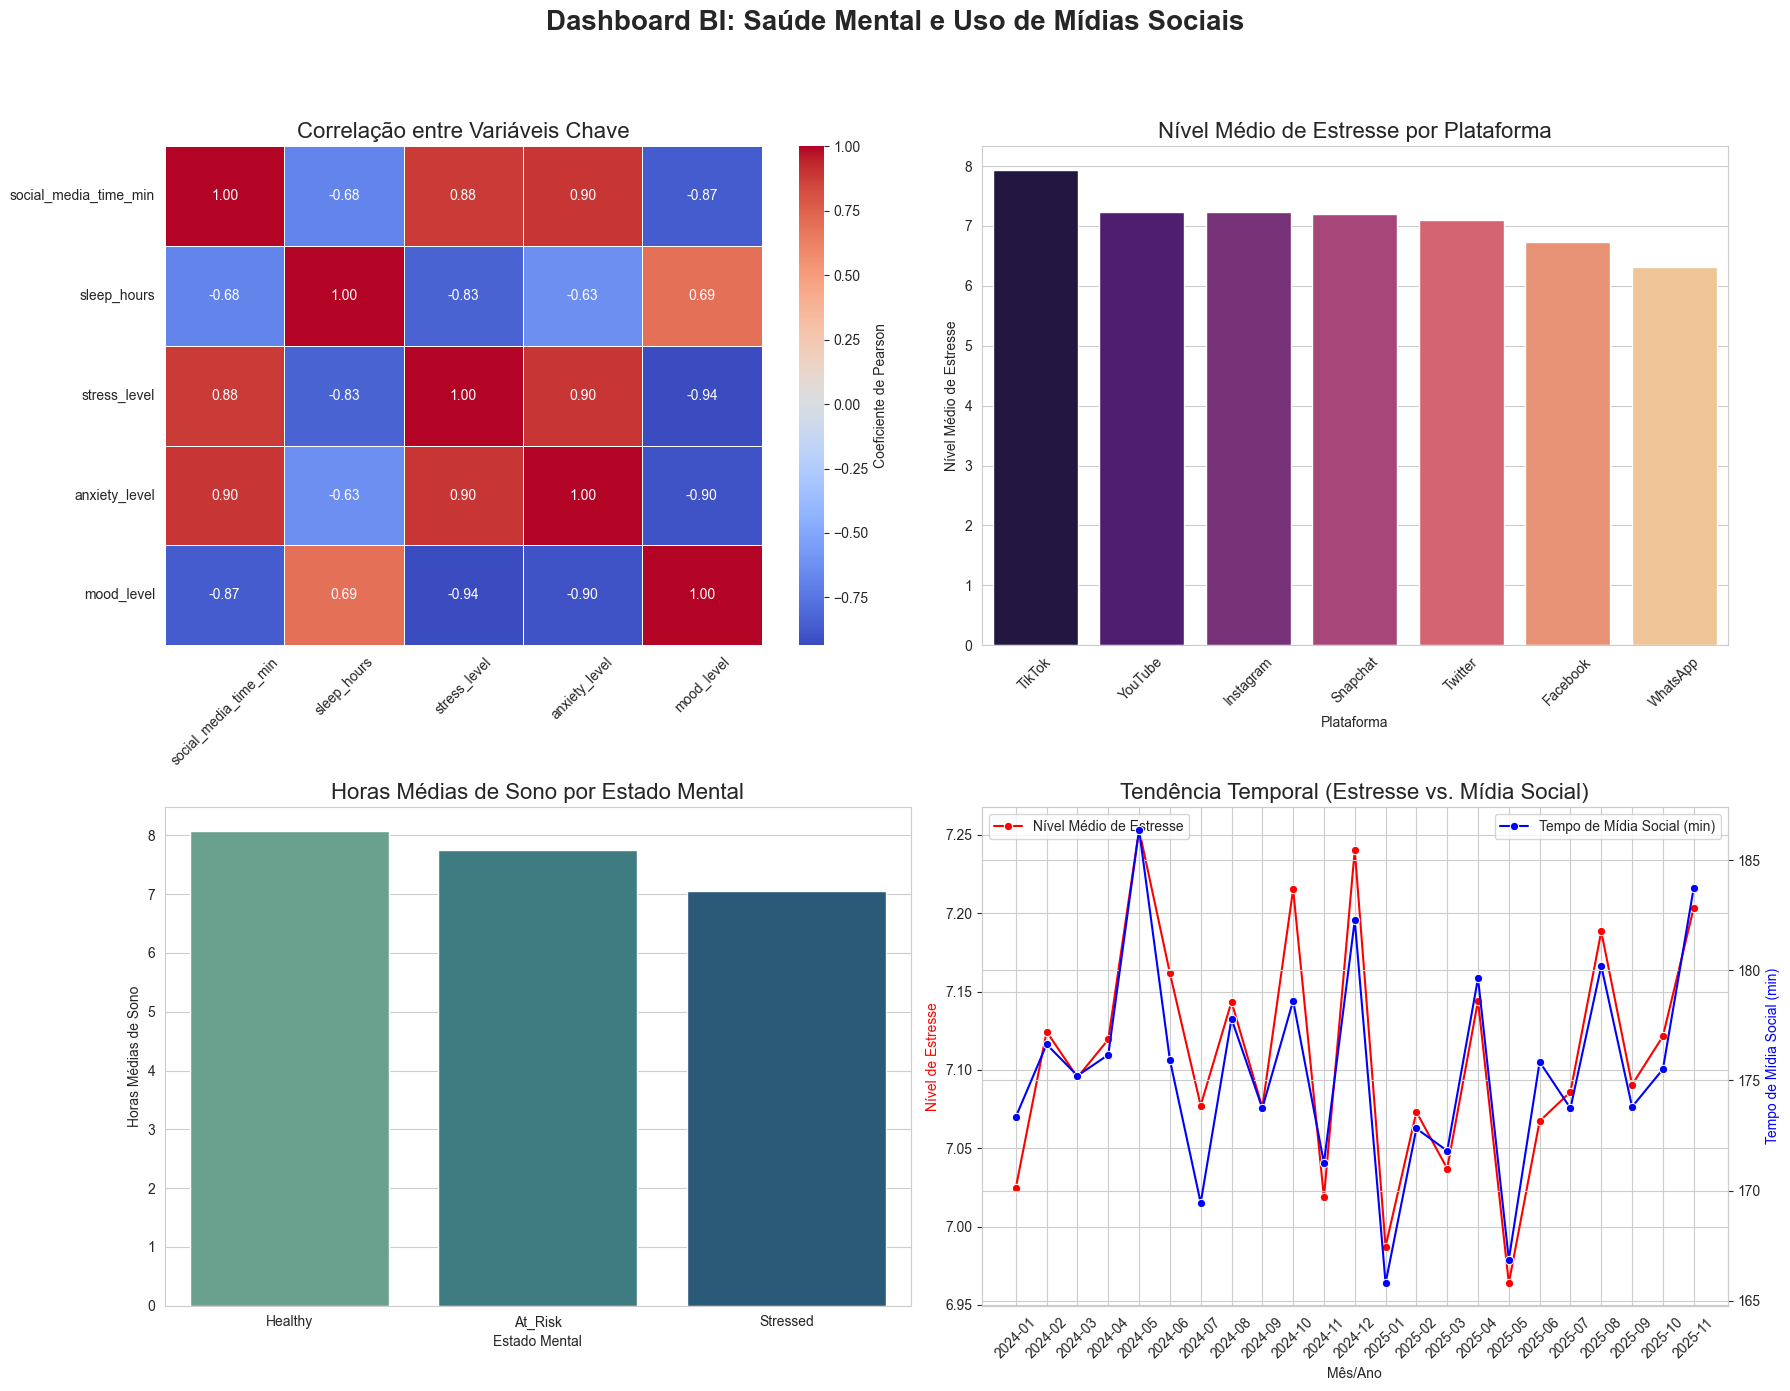

In [17]:
#Painel BI
#Configurações de estilo
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100 # Melhor resolução

#Carregar o dataset (Recriação do ambiente)
df['date'] = pd.to_datetime(df['date'])
df['year_month'] = df['date'].dt.to_period('M').astype(str)

#Dados para o Painel

#Matriz de Correlação
correlation_cols = [
    'social_media_time_min',
    'sleep_hours',
    'stress_level',
    'anxiety_level',
    'mood_level'
]
correlation_matrix = df[correlation_cols].corr()

#Stress por Plataforma
stress_by_platform = df.groupby('platform')['stress_level'].mean().sort_values(ascending=False).reset_index()

#Sono por Estado Mental
sleep_by_state = df.groupby('mental_state')['sleep_hours'].mean().sort_values(ascending=False).reset_index()
state_order = sleep_by_state['mental_state'] # Ordem para o gráfico

#Tendência Temporal
temporal_trends = df.groupby('year_month')[['stress_level', 'social_media_time_min']].mean().reset_index()


#Criação do Painel (4 Subplots)
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
plt.suptitle('Dashboard BI: Saúde Mental e Uso de Mídias Sociais', fontsize=20, y=1.02, fontweight='bold')

#HEATMAP DE CORRELAÇÃO
sns.heatmap(correlation_matrix,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            linewidths=.5,
            ax=axes[0, 0],
            cbar_kws={'label': 'Coeficiente de Pearson'})
axes[0, 0].set_title('Correlação entre Variáveis Chave', fontsize=16)
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].tick_params(axis='y', rotation=0)

#NÍVEL DE ESTRESSE POR PLATAFORMA
sns.barplot(x='platform', y='stress_level', data=stress_by_platform, palette='magma', ax=axes[0, 1])
axes[0, 1].set_title('Nível Médio de Estresse por Plataforma', fontsize=16)
axes[0, 1].set_xlabel('Plataforma')
axes[0, 1].set_ylabel('Nível Médio de Estresse')
axes[0, 1].tick_params(axis='x', rotation=45)

#HORAS DE SONO POR ESTADO MENTAL
sns.barplot(x='mental_state', y='sleep_hours', data=sleep_by_state, palette='crest', order=state_order, ax=axes[1, 0])
axes[1, 0].set_title('Horas Médias de Sono por Estado Mental', fontsize=16)
axes[1, 0].set_xlabel('Estado Mental')
axes[1, 0].set_ylabel('Horas Médias de Sono')

#TENDÊNCIA TEMPORAL (Estresse vs. Mídia Social)
ax4 = axes[1, 1]
sns.lineplot(x='year_month', y='stress_level', data=temporal_trends, marker='o', color='red', label='Nível Médio de Estresse', ax=ax4)
ax4_twin = ax4.twinx() # Segundo eixo Y para o tempo de mídia social
sns.lineplot(x='year_month', y='social_media_time_min', data=temporal_trends, marker='o', color='blue', label='Tempo de Mídia Social (min)', ax=ax4_twin)

ax4.set_title('Tendência Temporal (Estresse vs. Mídia Social)', fontsize=16)
ax4.set_xlabel('Mês/Ano')
ax4.set_ylabel('Nível de Estresse', color='red')
ax4_twin.set_ylabel('Tempo de Mídia Social (min)', color='blue')
ax4.tick_params(axis='x', rotation=45)
ax4.legend(loc='upper left')
ax4_twin.legend(loc='upper right')

#Ajustar layout para evitar sobreposição
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

# Conclusão 

O modelo sugere que a redução do estresse e o aumento das horas de sono estão fortemente ligados a uma transição do estado estressado para um estado mais neutro (e, em uma intervenção ainda mais extrema, possivelmente para o estado Calm).
O uso excessivo de mídias sociais está fortemente associado a piores resultados de saúde mental, impulsionado principalmente por um aumento nos níveis de estresse e uma redução drástica nas horas de sono.

# **Nathália Sorg**